# Steam Data Processing Pipeline (2021-2025)

This notebook performs comprehensive data processing on the Steam games dataset following standard data science practices:
1. **Data Loading** - Import and initial inspection
2. **Data Exploration** - Understanding the structure and content
3. **Data Cleaning** - Handle missing values, duplicates, and data types
4. **Data Transformation** - Organize and process for analysis
5. **Data Validation** - Quality checks and final preparation

## 1. Import Required Libraries

In [49]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Date and time handling
from datetime import datetime

# Data quality and warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Data

In [50]:
# Load the CSV file with semicolon delimiter
df = pd.read_csv('data/a_steam_data_2021_2025.csv', sep=';')

print(f"Data loaded successfully!")
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")

Data loaded successfully!
Dataset shape: 65521 rows × 10 columns


## 3. Initial Data Exploration

In [51]:
# Display first few rows
print("="*80)
print("FIRST 5 ROWS")
print("="*80)
display(df.head())

print("\n" + "="*80)
print("LAST 5 ROWS")
print("="*80)
display(df.tail())

FIRST 5 ROWS


,appid,name,release_year,release_date,genres,categories,price,recommendations,developer,publisher
0,3057270,Seafarer's Gambit,2024,"Jul 5, 2024",Action;Adventure;Indie;RPG;Strategy,Single-player;Family Sharing,3.99,0,Bouncy Rocket Studios,Bouncy Rocket Studios
1,3822840,Capitalist Misadventures,2025,"Jul 25, 2025",Casual;Indie;Simulation;Strategy,Single-player;Save Anytime;Family Sharing,7.99,0,Caramelo Studios,Caramelo Studios
2,3216640,The Beast and the Princess,2025,"Jun 17, 2025",Adventure;Indie;Strategy,Single-player;Steam Achievements;Full controll...,12.99,0,Libragames,Libragames
3,2403620,Air Twister,2023,"Nov 10, 2023",Action;Adventure;Indie,Single-player;Steam Achievements;Full controll...,24.99,0,YS Net,ININ
4,1538040,Horde Slayer,2021,"Mar 19, 2021",Action;Adventure;Casual;Indie;RPG;Early Access,Single-player;Steam Achievements;Full controll...,3.99,0,Wagner Rodrigues,Wagner Rodrigues



LAST 5 ROWS


,appid,name,release_year,release_date,genres,categories,price,recommendations,developer,publisher
65516,3097010,X Simulator Drone,2024,"Jul 31, 2024",Casual;Indie;Simulation,Single-player;Family Sharing,14.99,0,Inonia Games,Inonia Games
65517,3304930,Retro Dungeon Slayer,2025,"Mar 3, 2025",Action;Indie;Early Access,Single-player;Family Sharing,4.99,0,Hard Shark Games,Hard Shark Games
65518,1461580,Molecule Builder,2021,"Feb 4, 2021",Simulation;Education,Single-player;Tracked Controller Support;VR On...,14.99,0,Xennial Digital,Xennial Digital
65519,1379120,MechNest,2024,"Apr 13, 2024",Action;Indie,Single-player;Partial Controller Support;Famil...,15.99,0,PoisonGames,PoisonGames
65520,1580420,Ambidextrous Psychopath,2021,"Jun 28, 2021",Casual;Indie,Single-player;Family Sharing,0.99,0,Rylan Yancey,Rylan Yancey


In [52]:
# Basic information about the dataset
print("="*80)
print("DATASET INFORMATION")
print("="*80)
df.info()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65521 entries, 0 to 65520
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   appid            65521 non-null  int64  
 1   name             65521 non-null  object 
 2   release_year     65521 non-null  int64  
 3   release_date     65521 non-null  object 
 4   genres           65455 non-null  object 
 5   categories       65514 non-null  object 
 6   price            65521 non-null  float64
 7   recommendations  65521 non-null  int64  
 8   developer        65468 non-null  object 
 9   publisher        65338 non-null  object 
dtypes: float64(1), int64(3), object(6)
memory usage: 5.0+ MB


In [53]:
# Statistical summary
print("="*80)
print("STATISTICAL SUMMARY")
print("="*80)
display(df.describe())

print("\n" + "="*80)
print("COLUMN DATA TYPES")
print("="*80)
print(df.dtypes)

STATISTICAL SUMMARY


,appid,release_year,price,recommendations
count,6.552100e+04,65521.000000,65521.000000,65521.000000
mean,2.580607e+06,2023.453091,7.204043,362.165336
std,7.692480e+05,1.386641,16.914429,6936.837198
min,1.200220e+06,2021.000000,0.000000,0.000000
25%,1.916970e+06,2022.000000,0.990000,0.000000
50%,2.516050e+06,2024.000000,3.990000,0.000000
75%,3.193800e+06,2025.000000,9.740000,0.000000
max,4.243930e+06,2025.000000,1900.000000,862487.000000



COLUMN DATA TYPES
appid                int64
name                object
release_year         int64
release_date        object
genres              object
categories          object
price              float64
recommendations      int64
developer           object
publisher           object
dtype: object


## 4. Data Quality Assessment

In [54]:
# Check for missing values
print("="*80)
print("MISSING VALUES ANALYSIS")
print("="*80)

missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_data) > 0:
    display(missing_data)
else:
    print("No missing values found!")
    
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

MISSING VALUES ANALYSIS


,Column,Missing_Count,Missing_Percentage
publisher,publisher,183,0.28
genres,genres,66,0.10
developer,developer,53,0.08
categories,categories,7,0.01



Total missing values: 309


In [55]:
# Check for duplicate rows
print("="*80)
print("DUPLICATE ROWS ANALYSIS")
print("="*80)

duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    print(f"Percentage of duplicates: {(duplicate_count/len(df)*100):.2f}%")
    print("\nSample duplicate rows:")
    display(df[df.duplicated(keep=False)].head(10))
else:
    print("No duplicate rows found!")

DUPLICATE ROWS ANALYSIS
Number of duplicate rows: 0
No duplicate rows found!


In [56]:
# Check unique values in categorical columns
print("="*80)
print("UNIQUE VALUES IN CATEGORICAL COLUMNS")
print("="*80)

categorical_cols = ['name', 'genres', 'categories', 'developer', 'publisher']
for col in categorical_cols:
    if col in df.columns:
        print(f"\n{col.upper()}:")
        print(f"  - Unique values: {df[col].nunique()}")
        print(f"  - Sample values: {df[col].value_counts().head(3).to_dict()}")

UNIQUE VALUES IN CATEGORICAL COLUMNS

NAME:
  - Unique values: 65128
  - Sample values: {'Zombie Hunter': 5, 'Echoes': 5, 'Escape': 4}

GENRES:
  - Unique values: 1723
  - Sample values: {'Casual;Indie': 4136, 'Action;Adventure;Indie': 2883, 'Action;Indie': 2632}

CATEGORIES:
  - Unique values: 7993
  - Sample values: {'Single-player;Family Sharing': 15071, 'Single-player;Steam Achievements;Family Sharing': 6242, 'Single-player': 3164}

DEVELOPER:
  - Unique values: 45673
  - Sample values: {'EroticGamesClub': 215, 'Bully Revenge Studios': 119, 'Gamesforgames': 96}

PUBLISHER:
  - Unique values: 41584
  - Sample values: {'EroticGamesClub': 215, 'BFG Entertainment': 172, '8floor': 150}


## 5. Data Cleaning

In [57]:
# Create a copy for cleaning
df_clean = df.copy()

print("="*80)
print("STEP 1: REMOVING DUPLICATES")
print("="*80)

# Remove duplicate rows
initial_rows = len(df_clean)
df_clean = df_clean.drop_duplicates()
removed_duplicates = initial_rows - len(df_clean)
print(f"Removed {removed_duplicates} duplicate rows")
print(f"Remaining rows: {len(df_clean)}")

STEP 1: REMOVING DUPLICATES
Removed 0 duplicate rows
Remaining rows: 65521


In [58]:
print("\n" + "="*80)
print("STEP 2: HANDLING MISSING VALUES")
print("="*80)

# Fill missing values strategically
# For developer/publisher, use 'Unknown'
if 'developer' in df_clean.columns:
    missing_dev = df_clean['developer'].isnull().sum()
    df_clean['developer'] = df_clean['developer'].fillna('Unknown')
    print(f"Filled {missing_dev} missing developer values with 'Unknown'")

if 'publisher' in df_clean.columns:
    missing_pub = df_clean['publisher'].isnull().sum()
    df_clean['publisher'] = df_clean['publisher'].fillna('Unknown')
    print(f"Filled {missing_pub} missing publisher values with 'Unknown'")

# For genres/categories, use 'Unspecified'
if 'genres' in df_clean.columns:
    missing_genres = df_clean['genres'].isnull().sum()
    df_clean['genres'] = df_clean['genres'].fillna('Unspecified')
    print(f"Filled {missing_genres} missing genres values with 'Unspecified'")

if 'categories' in df_clean.columns:
    missing_cats = df_clean['categories'].isnull().sum()
    df_clean['categories'] = df_clean['categories'].fillna('Unspecified')
    print(f"Filled {missing_cats} missing categories values with 'Unspecified'")

# For numeric columns (price, recommendations), use 0
if 'price' in df_clean.columns:
    missing_price = df_clean['price'].isnull().sum()
    df_clean['price'] = df_clean['price'].fillna(0)
    print(f"Filled {missing_price} missing price values with 0")

if 'recommendations' in df_clean.columns:
    missing_rec = df_clean['recommendations'].isnull().sum()
    df_clean['recommendations'] = df_clean['recommendations'].fillna(0)
    print(f"Filled {missing_rec} missing recommendations values with 0")

print(f"\nTotal missing values remaining: {df_clean.isnull().sum().sum()}")


STEP 2: HANDLING MISSING VALUES
Filled 53 missing developer values with 'Unknown'
Filled 183 missing publisher values with 'Unknown'
Filled 66 missing genres values with 'Unspecified'
Filled 7 missing categories values with 'Unspecified'
Filled 0 missing price values with 0
Filled 0 missing recommendations values with 0

Total missing values remaining: 0


In [59]:
print("\n" + "="*80)
print("STEP 3: DATA TYPE CONVERSION")
print("="*80)

# Ensure correct data types
if 'appid' in df_clean.columns:
    df_clean['appid'] = df_clean['appid'].astype('int64')
    print("✓ appid converted to int64")

if 'release_year' in df_clean.columns:
    df_clean['release_year'] = pd.to_numeric(df_clean['release_year'], errors='coerce')
    print("✓ release_year converted to numeric")

if 'price' in df_clean.columns:
    df_clean['price'] = pd.to_numeric(df_clean['price'], errors='coerce').fillna(0)
    print("✓ price converted to numeric")

if 'recommendations' in df_clean.columns:
    df_clean['recommendations'] = pd.to_numeric(df_clean['recommendations'], errors='coerce').fillna(0).astype('int64')
    print("✓ recommendations converted to int64")

# Convert text columns to string type
text_columns = ['name', 'release_date', 'genres', 'categories', 'developer', 'publisher']
for col in text_columns:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype('str')
        
print("✓ All text columns converted to string type")


STEP 3: DATA TYPE CONVERSION
✓ appid converted to int64
✓ release_year converted to numeric
✓ price converted to numeric
✓ recommendations converted to int64
✓ All text columns converted to string type


In [60]:
print("\n" + "="*80)
print("STEP 4: TEXT CLEANING")
print("="*80)

# Strip whitespace from string columns
text_columns = ['name', 'genres', 'categories', 'developer', 'publisher']
for col in text_columns:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].str.strip()
        
print("✓ Removed leading/trailing whitespace from text columns")

# Remove rows with invalid app names (if any)
if 'name' in df_clean.columns:
    invalid_names = df_clean['name'].isin(['nan', 'None', '', 'Unknown'])
    removed_invalid = invalid_names.sum()
    df_clean = df_clean[~invalid_names]
    print(f"✓ Removed {removed_invalid} rows with invalid game names")

print(f"\nCleaned dataset shape: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns")


STEP 4: TEXT CLEANING
✓ Removed leading/trailing whitespace from text columns
✓ Removed 1 rows with invalid game names

Cleaned dataset shape: 65520 rows × 10 columns


In [61]:
print("\n" + "="*80)
print("STEP 5: VALIDATING CRITICAL FIELDS & FILTERING INVALID ENTRIES")
print("="*80)

# Define what constitutes invalid values
invalid_values = ['nan', 'None', '', 'Unknown', 'Unspecified', 'N/A', 'NA']

# Split genres by semicolon for better analysis
if 'genres' in df_clean.columns:
    # First, split the genres
    df_clean['genres_split'] = df_clean['genres'].str.split(';').apply(
        lambda x: [g.strip() for g in x] if isinstance(x, list) else []
    )
    print("✓ Split genres by semicolon for better analysis")

# Check for valid genre (REQUIRED - games without valid genre will be separated)
if 'genres' in df_clean.columns:
    # A valid genre means: not empty, not in invalid_values list, and has actual content
    valid_genre_mask = (
        (~df_clean['genres'].isin(invalid_values)) & 
        (df_clean['genres'].str.len() > 0) &
        (df_clean['genres'].notna())
    )
    
    # Separate invalid entries (no valid genre)
    df_invalid = df_clean[~valid_genre_mask].copy()
    df_clean = df_clean[valid_genre_mask].copy()
    
    print(f"✓ Separated {len(df_invalid)} games WITHOUT valid genre (saved separately)")
    print(f"✓ Retained {len(df_clean)} games WITH valid genre")

# For developer and publisher, just flag them but don't remove
if 'developer' in df_clean.columns:
    invalid_dev = df_clean['developer'].isin(invalid_values)
    df_clean['has_valid_developer'] = (~invalid_dev).astype(int)
    print(f"✓ Flagged games with valid developer: {df_clean['has_valid_developer'].sum():,}")

if 'publisher' in df_clean.columns:
    invalid_pub = df_clean['publisher'].isin(invalid_values)
    df_clean['has_valid_publisher'] = (~invalid_pub).astype(int)
    print(f"✓ Flagged games with valid publisher: {df_clean['has_valid_publisher'].sum():,}")

# Save the invalid entries dataset for reference
if len(df_invalid) > 0:
    invalid_output = 'data/steam_data_invalid_genre.csv'
    df_invalid.to_csv(invalid_output, sep=';', index=False, encoding='utf-8')
    print(f"\n✓ Invalid entries saved to: {invalid_output}")

print(f"\nFinal cleaned dataset shape: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns")


STEP 5: VALIDATING CRITICAL FIELDS & FILTERING INVALID ENTRIES
✓ Split genres by semicolon for better analysis
✓ Separated 66 games WITHOUT valid genre (saved separately)
✓ Retained 65454 games WITH valid genre
✓ Flagged games with valid developer: 65,408
✓ Flagged games with valid publisher: 65,278

✓ Invalid entries saved to: data/steam_data_invalid_genre.csv

Final cleaned dataset shape: 65454 rows × 13 columns


## 6. Data Transformation & Feature Engineering

In [62]:
print("="*80)
print("CREATING NEW FEATURES")
print("="*80)

# 1. Use the already-split genres and add genre count
if 'genres_split' in df_clean.columns:
    df_clean['genres_list'] = df_clean['genres_split']  # Use the pre-split genres
    df_clean['genre_count'] = df_clean['genres_list'].apply(lambda x: len(x) if isinstance(x, list) else 0)
    print("✓ Using pre-split genres and created 'genre_count' feature")
elif 'genres' in df_clean.columns:
    # Fallback if genres_split doesn't exist
    df_clean['genres_list'] = df_clean['genres'].str.split(';')
    df_clean['genre_count'] = df_clean['genres_list'].apply(lambda x: len(x) if isinstance(x, list) else 0)
    print("✓ Created 'genres_list' and 'genre_count' features")

# 2. Parse categories into list
if 'categories' in df_clean.columns:
    df_clean['categories_list'] = df_clean['categories'].str.split(';')
    df_clean['category_count'] = df_clean['categories_list'].apply(lambda x: len(x) if isinstance(x, list) else 0)
    print("✓ Created 'categories_list' and 'category_count' features")

# 3. Price categories
if 'price' in df_clean.columns:
    df_clean['price_category'] = pd.cut(df_clean['price'], 
                                         bins=[-0.01, 0, 5, 15, 30, float('inf')],
                                         labels=['Free', 'Budget', 'Standard', 'Premium', 'Expensive'])
    print("✓ Created 'price_category' feature")

# 4. Popularity based on recommendations
if 'recommendations' in df_clean.columns:
    df_clean['popularity'] = pd.cut(df_clean['recommendations'],
                                     bins=[-1, 0, 100, 1000, 5000, float('inf')],
                                     labels=['None', 'Low', 'Medium', 'High', 'Very High'])
    print("✓ Created 'popularity' feature")

# 5. Check if game is free
if 'price' in df_clean.columns:
    df_clean['is_free'] = (df_clean['price'] == 0).astype(int)
    print("✓ Created 'is_free' feature")

# 6. Check for Early Access
if 'categories' in df_clean.columns:
    df_clean['is_early_access'] = df_clean['categories'].str.contains('Early Access', case=False, na=False).astype(int)
    print("✓ Created 'is_early_access' feature")

# 7. Check for multiplayer
if 'categories' in df_clean.columns:
    df_clean['is_multiplayer'] = df_clean['categories'].str.contains('Multi-player', case=False, na=False).astype(int)
    print("✓ Created 'is_multiplayer' feature")

print(f"\nNew dataset shape: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns")

CREATING NEW FEATURES
✓ Using pre-split genres and created 'genre_count' feature
✓ Created 'categories_list' and 'category_count' features
✓ Created 'price_category' feature
✓ Created 'popularity' feature
✓ Created 'is_free' feature
✓ Created 'is_early_access' feature
✓ Created 'is_multiplayer' feature

New dataset shape: 65454 rows × 22 columns


In [63]:
print("\n" + "="*80)
print("EXTRACTING PRIMARY GENRE")
print("="*80)

# Extract the primary (first) genre
if 'genres_list' in df_clean.columns:
    df_clean['primary_genre'] = df_clean['genres_list'].apply(
        lambda x: x[0] if isinstance(x, list) and len(x) > 0 else 'Unspecified'
    )
    print("✓ Created 'primary_genre' feature")
    print(f"\nTop 10 primary genres:")
    print(df_clean['primary_genre'].value_counts().head(10))


EXTRACTING PRIMARY GENRE
✓ Created 'primary_genre' feature

Top 10 primary genres:
primary_genre
Action                   25719
Casual                   15355
Adventure                14124
Indie                     6064
Simulation                1388
RPG                       1172
Strategy                   831
Free To Play               278
Racing                     277
Massively Multiplayer      123
Name: count, dtype: int64


## 7. Data Validation & Quality Checks

In [64]:
print("="*80)
print("VALIDATION CHECKS")
print("="*80)

# Check 1: No missing values in critical columns
critical_columns = ['appid', 'name', 'release_year']
missing_critical = df_clean[critical_columns].isnull().sum()
print("\n1. Missing values in critical columns:")
print(missing_critical)

# Check 2: Data type validation
print("\n2. Data type validation:")
print(df_clean.dtypes)

# Check 3: Value ranges
print("\n3. Value range validation:")
if 'price' in df_clean.columns:
    print(f"   Price: Min={df_clean['price'].min():.2f}, Max={df_clean['price'].max():.2f}")
if 'recommendations' in df_clean.columns:
    print(f"   Recommendations: Min={df_clean['recommendations'].min()}, Max={df_clean['recommendations'].max()}")
if 'release_year' in df_clean.columns:
    print(f"   Release Year: Min={df_clean['release_year'].min()}, Max={df_clean['release_year'].max()}")

# Check 4: Outliers in price
print("\n4. Price distribution:")
if 'price' in df_clean.columns:
    price_stats = df_clean['price'].describe()
    print(price_stats)
    
print("\n✓ All validation checks completed!")

VALIDATION CHECKS

1. Missing values in critical columns:
appid           0
name            0
release_year    0
dtype: int64

2. Data type validation:
appid                     int64
name                     object
release_year              int64
release_date             object
genres                   object
categories               object
price                   float64
recommendations           int64
developer                object
publisher                object
genres_split             object
has_valid_developer       int64
has_valid_publisher       int64
genres_list              object
genre_count               int64
categories_list          object
category_count            int64
price_category         category
popularity             category
is_free                   int64
is_early_access           int64
is_multiplayer            int64
primary_genre            object
dtype: object

3. Value range validation:
   Price: Min=0.00, Max=1900.00
   Recommendations: Min=0, Max=862487
 

In [65]:
#Verify the data cleaning
# Check unique values in categorical columns
print("="*80)
print("UNIQUE VALUES IN CATEGORICAL COLUMNS")
print("="*80)

categorical_cols = ['name', 'genres', 'categories', 'developer', 'publisher']
for col in categorical_cols:
    if col in df_clean.columns:
        print(f"\n{col.upper()}:")
        print(f"  - Unique values: {df_clean[col].nunique()}")
        print(f"  - Sample values: {df_clean[col].value_counts().head(3).to_dict()}")

UNIQUE VALUES IN CATEGORICAL COLUMNS

NAME:
  - Unique values: 65061
  - Sample values: {'Echoes': 5, 'Zombie Hunter': 5, 'Escape': 4}

GENRES:
  - Unique values: 1723
  - Sample values: {'Casual;Indie': 4136, 'Action;Adventure;Indie': 2883, 'Action;Indie': 2632}

CATEGORIES:
  - Unique values: 7991
  - Sample values: {'Single-player;Family Sharing': 15059, 'Single-player;Steam Achievements;Family Sharing': 6230, 'Single-player': 3164}

DEVELOPER:
  - Unique values: 45591
  - Sample values: {'EroticGamesClub': 215, 'Bully Revenge Studios': 119, 'Gamesforgames': 96}

PUBLISHER:
  - Unique values: 41288
  - Sample values: {'EroticGamesClub': 215, 'Unknown': 175, 'BFG Entertainment': 172}


## 8. Summary Statistics & Insights

In [66]:
print("="*80)
print("PROCESSED DATASET SUMMARY")
print("="*80)

print(f"\n📊 Dataset Overview:")
print(f"   Total games: {len(df_clean):,}")
print(f"   Total features: {df_clean.shape[1]}")
print(f"   Memory usage: {df_clean.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\n💰 Price Statistics:")
if 'price' in df_clean.columns:
    print(f"   Average price: ${df_clean['price'].mean():.2f}")
    print(f"   Median price: ${df_clean['price'].median():.2f}")
    print(f"   Free games: {(df_clean['price'] == 0).sum():,} ({(df_clean['price'] == 0).sum()/len(df_clean)*100:.1f}%)")

print(f"\n⭐ Recommendations Statistics:")
if 'recommendations' in df_clean.columns:
    print(f"   Average recommendations: {df_clean['recommendations'].mean():.0f}")
    print(f"   Median recommendations: {df_clean['recommendations'].median():.0f}")
    print(f"   Games with recommendations: {(df_clean['recommendations'] > 0).sum():,}")

print(f"\n📅 Release Year Distribution:")
if 'release_year' in df_clean.columns:
    year_dist = df_clean['release_year'].value_counts().sort_index()
    for year in sorted(df_clean['release_year'].unique()):
        if not pd.isna(year):
            count = (df_clean['release_year'] == year).sum()
            print(f"   {int(year)}: {count:,} games")

print(f"\n🎮 Top 10 Genres:")
if 'primary_genre' in df_clean.columns:
    top_genres = df_clean['primary_genre'].value_counts().head(10)
    for genre, count in top_genres.items():
        print(f"   {genre}: {count:,} ({count/len(df_clean)*100:.1f}%)")

PROCESSED DATASET SUMMARY

📊 Dataset Overview:
   Total games: 65,454
   Total features: 23
   Memory usage: 60.20 MB

💰 Price Statistics:
   Average price: $7.21
   Median price: $3.99
   Free games: 11,948 (18.3%)

⭐ Recommendations Statistics:
   Average recommendations: 362
   Median recommendations: 0
   Games with recommendations: 7,968

📅 Release Year Distribution:
   2021: 8,371 games
   2022: 9,599 games
   2023: 11,536 games
   2024: 15,846 games
   2025: 20,102 games

🎮 Top 10 Genres:
   Action: 25,719 (39.3%)
   Casual: 15,355 (23.5%)
   Adventure: 14,124 (21.6%)
   Indie: 6,064 (9.3%)
   Simulation: 1,388 (2.1%)
   RPG: 1,172 (1.8%)
   Strategy: 831 (1.3%)
   Free To Play: 278 (0.4%)
   Racing: 277 (0.4%)
   Massively Multiplayer: 123 (0.2%)


## 9. Data Visualization

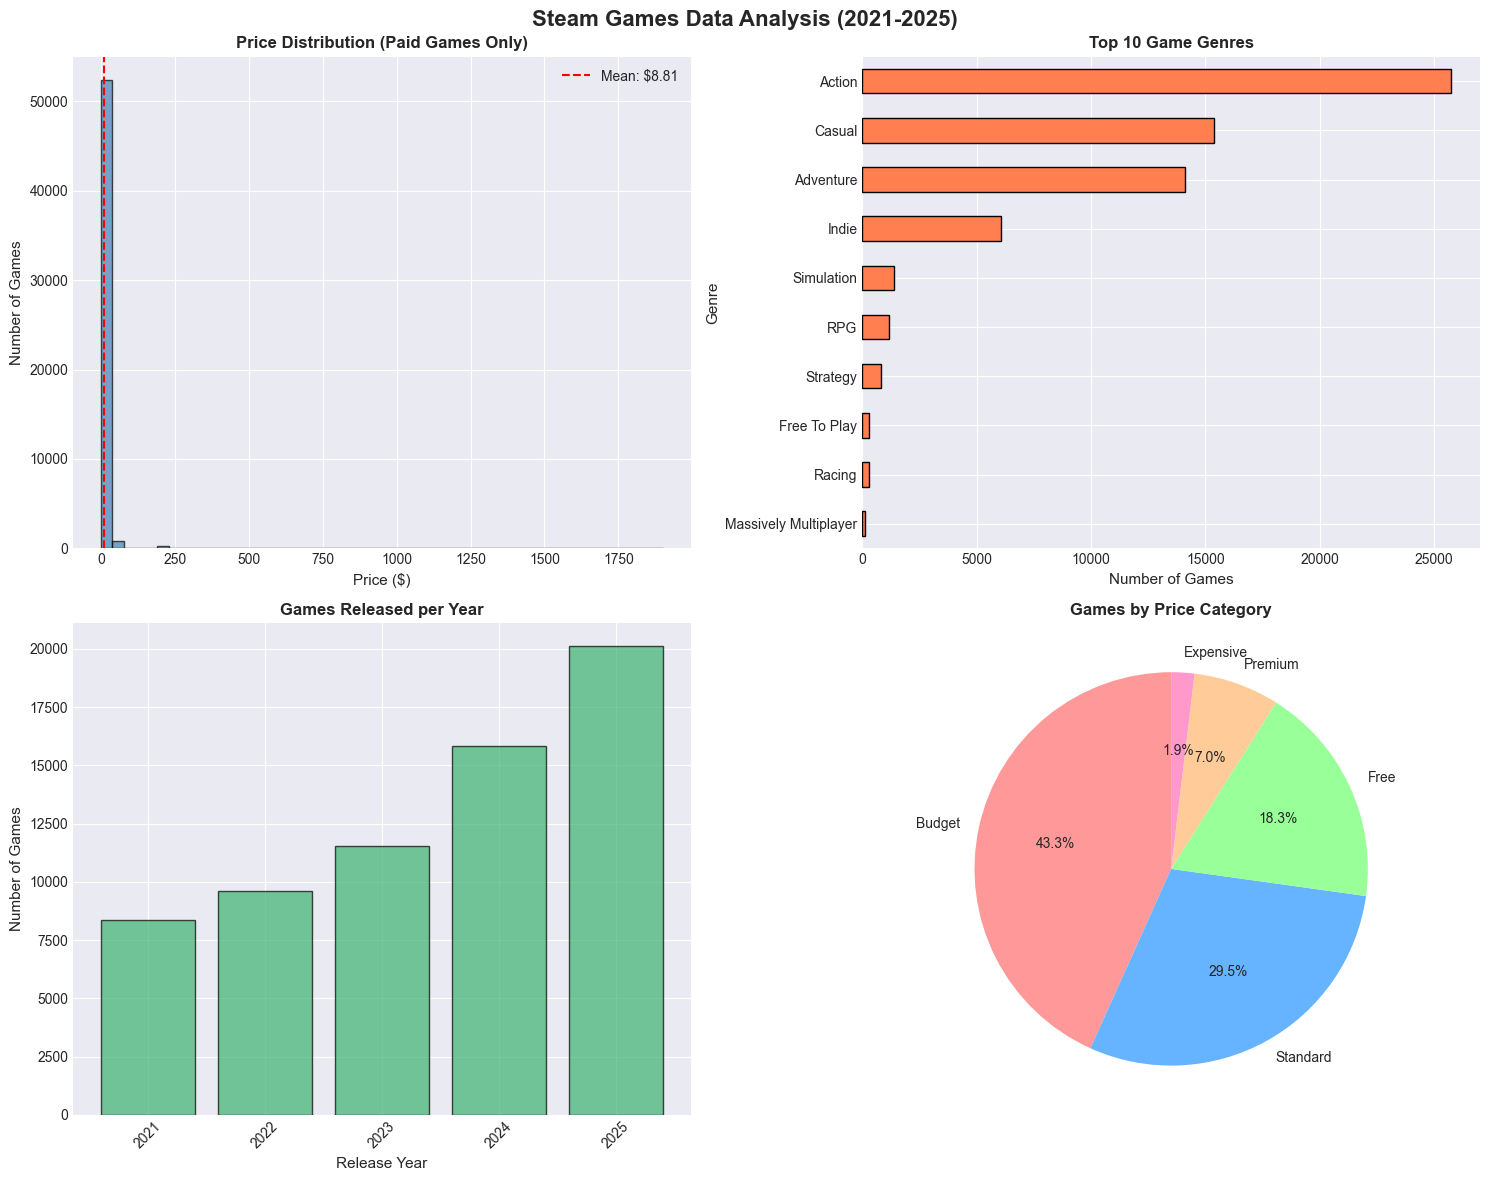

✓ Visualizations created successfully!


In [67]:
# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Steam Games Data Analysis (2021-2025)', fontsize=16, fontweight='bold')

# 1. Price Distribution
if 'price' in df_clean.columns:
    ax1 = axes[0, 0]
    price_data = df_clean[df_clean['price'] > 0]['price']  # Exclude free games
    ax1.hist(price_data, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    ax1.set_xlabel('Price ($)', fontsize=11)
    ax1.set_ylabel('Number of Games', fontsize=11)
    ax1.set_title('Price Distribution (Paid Games Only)', fontsize=12, fontweight='bold')
    ax1.axvline(price_data.mean(), color='red', linestyle='--', label=f'Mean: ${price_data.mean():.2f}')
    ax1.legend()

# 2. Top 10 Genres
if 'primary_genre' in df_clean.columns:
    ax2 = axes[0, 1]
    top_genres = df_clean['primary_genre'].value_counts().head(10)
    top_genres.plot(kind='barh', ax=ax2, color='coral', edgecolor='black')
    ax2.set_xlabel('Number of Games', fontsize=11)
    ax2.set_ylabel('Genre', fontsize=11)
    ax2.set_title('Top 10 Game Genres', fontsize=12, fontweight='bold')
    ax2.invert_yaxis()

# 3. Games by Release Year
if 'release_year' in df_clean.columns:
    ax3 = axes[1, 0]
    year_counts = df_clean['release_year'].value_counts().sort_index()
    ax3.bar(year_counts.index, year_counts.values, color='mediumseagreen', edgecolor='black', alpha=0.7)
    ax3.set_xlabel('Release Year', fontsize=11)
    ax3.set_ylabel('Number of Games', fontsize=11)
    ax3.set_title('Games Released per Year', fontsize=12, fontweight='bold')
    ax3.tick_params(axis='x', rotation=45)

# 4. Price Category Distribution
if 'price_category' in df_clean.columns:
    ax4 = axes[1, 1]
    price_cat_counts = df_clean['price_category'].value_counts()
    colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#ff99cc']
    ax4.pie(price_cat_counts.values, labels=price_cat_counts.index, autopct='%1.1f%%', 
            startangle=90, colors=colors)
    ax4.set_title('Games by Price Category', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Visualizations created successfully!")

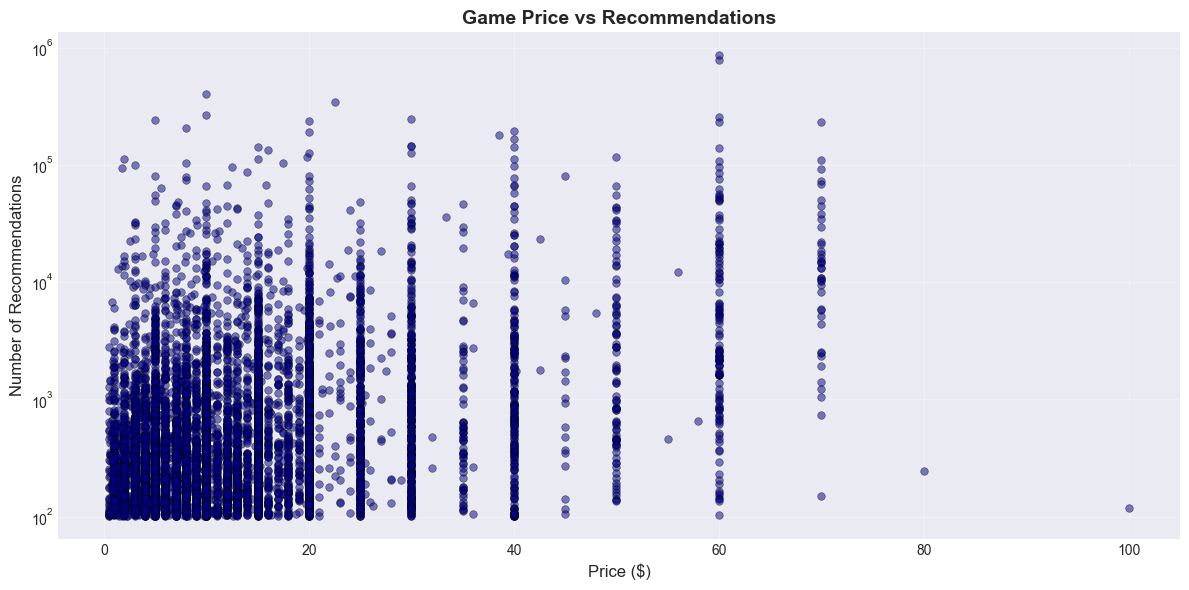

✓ Scatter plot created successfully!


In [68]:
# Additional visualization: Recommendations vs Price scatter plot
fig, ax = plt.subplots(figsize=(12, 6))

if 'price' in df_clean.columns and 'recommendations' in df_clean.columns:
    # Filter data for better visualization
    scatter_data = df_clean[(df_clean['recommendations'] > 0) & (df_clean['price'] > 0)]
    
    ax.scatter(scatter_data['price'], scatter_data['recommendations'], 
               alpha=0.5, s=30, c='darkblue', edgecolors='black', linewidth=0.5)
    ax.set_xlabel('Price ($)', fontsize=12)
    ax.set_ylabel('Number of Recommendations', fontsize=12)
    ax.set_title('Game Price vs Recommendations', fontsize=14, fontweight='bold')
    ax.set_yscale('log')  # Log scale for better visualization
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Scatter plot created successfully!")

## 10. Export Processed Data

In [69]:
# Save the cleaned and processed dataset
output_filename = 'data/steam_data_processed.csv'

df_clean.to_csv(output_filename, sep=';', index=False, encoding='utf-8')

print("="*80)
print("DATA EXPORT COMPLETED")
print("="*80)
print(f"✓ Processed data saved to: {output_filename}")
print(f"✓ Total records: {len(df_clean):,}")
print(f"✓ Total features: {df_clean.shape[1]}")
print("\n📋 Available columns:")
for i, col in enumerate(df_clean.columns, 1):
    print(f"   {i:2d}. {col}")

DATA EXPORT COMPLETED
✓ Processed data saved to: data/steam_data_processed.csv
✓ Total records: 65,454
✓ Total features: 23

📋 Available columns:
    1. appid
    2. name
    3. release_year
    4. release_date
    5. genres
    6. categories
    7. price
    8. recommendations
    9. developer
   10. publisher
   11. genres_split
   12. has_valid_developer
   13. has_valid_publisher
   14. genres_list
   15. genre_count
   16. categories_list
   17. category_count
   18. price_category
   19. popularity
   20. is_free
   21. is_early_access
   22. is_multiplayer
   23. primary_genre


In [70]:
# Display sample of the final processed data
print("\n" + "="*80)
print("SAMPLE OF PROCESSED DATA")
print("="*80)
display(df_clean.head(10))


SAMPLE OF PROCESSED DATA


,appid,name,release_year,release_date,genres,categories,price,recommendations,developer,publisher,genres_split,has_valid_developer,has_valid_publisher,genres_list,genre_count,categories_list,category_count,price_category,popularity,is_free,is_early_access,is_multiplayer,primary_genre
0,3057270,Seafarer's Gambit,2024,"Jul 5, 2024",Action;Adventure;Indie;RPG;Strategy,Single-player;Family Sharing,3.99,0,Bouncy Rocket Studios,Bouncy Rocket Studios,"[Action, Adventure, Indie, RPG, Strategy]",1,1,"[Action, Adventure, Indie, RPG, Strategy]",5,"[Single-player, Family Sharing]",2,Budget,None,0,0,0,Action
1,3822840,Capitalist Misadventures,2025,"Jul 25, 2025",Casual;Indie;Simulation;Strategy,Single-player;Save Anytime;Family Sharing,7.99,0,Caramelo Studios,Caramelo Studios,"[Casual, Indie, Simulation, Strategy]",1,1,"[Casual, Indie, Simulation, Strategy]",4,"[Single-player, Save Anytime, Family Sharing]",3,Standard,None,0,0,0,Casual
2,3216640,The Beast and the Princess,2025,"Jun 17, 2025",Adventure;Indie;Strategy,Single-player;Steam Achievements;Full controll...,12.99,0,Libragames,Libragames,"[Adventure, Indie, Strategy]",1,1,"[Adventure, Indie, Strategy]",3,"[Single-player, Steam Achievements, Full contr...",9,Standard,None,0,0,0,Adventure
3,2403620,Air Twister,2023,"Nov 10, 2023",Action;Adventure;Indie,Single-player;Steam Achievements;Full controll...,24.99,0,YS Net,ININ,"[Action, Adventure, Indie]",1,1,"[Action, Adventure, Indie]",3,"[Single-player, Steam Achievements, Full contr...",5,Premium,None,0,0,0,Action
4,1538040,Horde Slayer,2021,"Mar 19, 2021",Action;Adventure;Casual;Indie;RPG;Early Access,Single-player;Steam Achievements;Full controll...,3.99,0,Wagner Rodrigues,Wagner Rodrigues,"[Action, Adventure, Casual, Indie, RPG, Early ...",1,1,"[Action, Adventure, Casual, Indie, RPG, Early ...",6,"[Single-player, Steam Achievements, Full contr...",5,Budget,None,0,0,0,Action
5,1724980,The Lone Blade,2023,"May 23, 2023",Action;Adventure;Indie,Single-player;Full controller support;Family S...,1.99,0,Opia Games,Opia Games;Plug In Digital,"[Action, Adventure, Indie]",1,1,"[Action, Adventure, Indie]",3,"[Single-player, Full controller support, Famil...",3,Budget,None,0,0,0,Action
6,3822820,Knight Crawler,2025,"Jul 16, 2025",Action;Indie;Free To Play,Single-player;Full controller support;Custom V...,0.00,0,Taylor Conolley,Taylor Conolley,"[Action, Indie, Free To Play]",1,1,"[Action, Indie, Free To Play]",3,"[Single-player, Full controller support, Custo...",5,Free,None,1,0,0,Action
7,3863460,No Sweet Looks,2025,"Aug 28, 2025",Action;Indie,Single-player;Steam Achievements;Full controll...,2.99,0,halvardo13,halvardo13,"[Action, Indie]",1,1,"[Action, Indie]",2,"[Single-player, Steam Achievements, Full contr...",7,Budget,None,0,0,0,Action
8,3216610,League Of Tacticians: Path of Tarkan,2025,"May 21, 2025",Adventure;RPG;Strategy,Single-player;Family Sharing,3.99,0,Oba Games,Oba Games,"[Adventure, RPG, Strategy]",1,1,"[Adventure, RPG, Strategy]",3,"[Single-player, Family Sharing]",2,Budget,None,0,0,0,Adventure
9,3057250,Pennylooter,2025,"Sep 8, 2025",Action;Indie,Single-player;Steam Achievements;Full controll...,6.99,0,Josh Sellers,Josh Sellers,"[Action, Indie]",1,1,"[Action, Indie]",2,"[Single-player, Steam Achievements, Full contr...",5,Standard,None,0,0,0,Action


In [71]:
# Verify that genres and categories are now vectors (lists)
print("="*80)
print("VERIFYING GENRES AND CATEGORIES AS VECTORS")
print("="*80)

# Check a sample row
sample_row = df_clean.iloc[0]

print("\n📌 Example from first game:")
print(f"Game: {sample_row['name']}")
print(f"\nOriginal genres string: {sample_row['genres']}")
print(f"Genres as list: {sample_row['genres_list']}")
print(f"Type: {type(sample_row['genres_list'])}")
print(f"Number of genres: {len(sample_row['genres_list'])}")

print(f"\nOriginal categories string: {sample_row['categories']}")
print(f"Categories as list: {sample_row['categories_list']}")
print(f"Type: {type(sample_row['categories_list'])}")
print(f"Number of categories: {len(sample_row['categories_list'])}")

print("\n" + "="*80)
print("✓ Yes! Genres and categories are now vectors (lists) of individual elements")
print("="*80)

VERIFYING GENRES AND CATEGORIES AS VECTORS

📌 Example from first game:
Game: Seafarer's Gambit

Original genres string: Action;Adventure;Indie;RPG;Strategy
Genres as list: ['Action', 'Adventure', 'Indie', 'RPG', 'Strategy']
Type: <class 'list'>
Number of genres: 5

Original categories string: Single-player;Family Sharing
Categories as list: ['Single-player', 'Family Sharing']
Type: <class 'list'>
Number of categories: 2

✓ Yes! Genres and categories are now vectors (lists) of individual elements


## 📝 Processing Summary

### What Was Done:

1. **Data Loading** ✓
   - Loaded Steam games dataset (2021-2025)
   - Handled semicolon-delimited CSV format

2. **Data Cleaning** ✓
   - Removed duplicate entries
   - Handled missing values strategically
   - Converted data types appropriately
   - Cleaned text fields (whitespace, invalid entries)
   - **Split genres by semicolon** for better analysis
   - **Validated critical fields** (genre, developer, publisher)
   - **Separated games without valid genre** to separate dataset (`steam_data_invalid_genre.csv`)
   - Added validation flags for developer and publisher

3. **Feature Engineering** ✓
   - Parsed genres and categories into lists
   - Created genre/category count features
   - Added price categories (Free, Budget, Standard, Premium, Expensive)
   - Created popularity levels based on recommendations
   - Added binary flags (is_free, is_early_access, is_multiplayer)
   - Extracted primary genre for each game

4. **Data Validation** ✓
   - Verified no missing critical values
   - Checked data type consistency
   - Validated value ranges
   - Identified outliers

5. **Data Visualization** ✓
   - Price distribution analysis
   - Genre popularity breakdown
   - Release year trends
   - Price vs recommendations correlation

6. **Export** ✓
   - Saved processed dataset for future analysis
   - Dataset ready for machine learning, analytics, or reporting

### Next Steps:
- Use `df_clean` for any further analysis
- The processed data is saved in `data/steam_data_processed.csv`
- Ready for predictive modeling, dashboard creation, or statistical analysis